# WellMind AI - 3. Clustering (Unsupervised)

Groups users into lifestyle clusters based on their sleep, activity and stress numbers, instead of predicting a fixed label.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import sys
from pathlib import Path
_nb = Path.cwd()
sys.path.insert(0, str(_nb if (_nb / "paths.py").exists() else _nb / "notebook"))
from paths import RAW_CSV, CLUSTERING_RESULTS_CSV

RANDOM_STATE = 42


## 1. Rebuild the Same Engineered Features

We redo the cleaning + wellness score steps from notebook 1, quickly, so this notebook can also run on its own.

In [35]:
df = pd.read_csv(RAW_CSV)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

gender_map = {"m": "Male", "male": "Male", "f": "Female", "female": "Female"}
df["Gender"] = df["Gender"].str.lower().map(gender_map).fillna(df["Gender"].str.title())

num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()
if "Person ID" in df.columns:
    df = df.drop(columns=["Person ID"])

def sleep_hours_points(hours):
    if hours < 5:
        return 30
    elif hours < 7:
        return 55
    elif hours <= 9:
        return 90
    else:
        return 70

df["Sleep Score"] = df["Sleep Duration"].apply(sleep_hours_points) * 0.5 + (df["Quality of Sleep"] / 10 * 100) * 0.5
pal_norm = ((df["Physical Activity Level"].clip(30, 90) - 30) / 60) * 100
steps_norm = (df["Daily Steps"] / 10000 * 100).clip(0, 100)
df["Activity Score"] = pal_norm * 0.5 + steps_norm * 0.5
df["Stress Index"] = df["Stress Level"] * 10
df["Fatigue Score"] = (100 - df["Sleep Score"]) * 0.4 + df["Stress Index"] * 0.35 + (100 - df["Activity Score"]) * 0.25
df["Wellness Score"] = (
    df["Sleep Score"] * 0.35 + df["Activity Score"] * 0.30
    + (100 - df["Stress Index"]) * 0.20 + (100 - df["Fatigue Score"]) * 0.15
).clip(0, 100)

print(f"Loaded and engineered {df.shape[0]} rows, {df.shape[1]} columns.")


Loaded and engineered 15000 rows, 17 columns.


## 2. Select Features & Cap Outliers

In [36]:
cluster_cols = [
    "Sleep Duration", "Quality of Sleep", "Physical Activity Level", "Stress Level",
    "Daily Steps", "Sleep Score", "Activity Score", "Stress Index", "Wellness Score",
]

cluster_df = df[cluster_cols].copy()

def cap_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

for col in cluster_df.columns:
    cluster_df[col] = cap_iqr(cluster_df[col])

cluster_df.describe()


,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Daily Steps,Sleep Score,Activity Score,Stress Index,Wellness Score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,6.997327,7.131267,59.925000,5.654800,6795.880000,71.929667,58.912900,56.548000,60.345897
std,0.615187,1.053111,16.814374,1.393568,1327.673607,13.484566,19.748848,13.935685,11.855440
min,5.800000,4.000000,30.000000,3.000000,3600.000000,47.500000,15.000000,30.000000,29.587500
25%,6.500000,6.000000,45.000000,4.000000,6000.000000,57.500000,42.500000,40.000000,48.300000
50%,7.000000,7.000000,60.000000,6.000000,6500.000000,75.000000,57.500000,60.000000,62.375000
75%,7.450000,8.000000,75.000000,6.000000,7600.000000,85.000000,72.500000,60.000000,71.937500
max,8.500000,9.000000,90.000000,8.000000,10000.000000,90.000000,100.000000,80.000000,88.325000


## 3. Scale the Features

In [37]:
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

print("Scaled shape:", cluster_scaled.shape)


Scaled shape: (15000, 9)


## 4. Elbow Method - Choosing the Number of Clusters

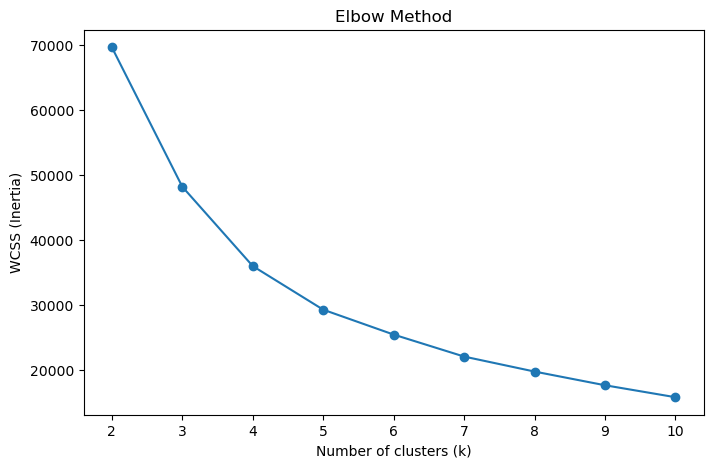

In [38]:
wcss = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(cluster_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.show()

# Pick k=4 lifestyle groups, based on where the elbow bends
best_k = 4


## 5. Fit KMeans & Agglomerative Clustering

In [39]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(cluster_scaled)

agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(cluster_scaled)

print("KMeans Silhouette Score:", silhouette_score(cluster_scaled, kmeans_labels))
print("Agglomerative Silhouette Score:", silhouette_score(cluster_scaled, agg_labels))
print("KMeans Davies-Bouldin Index:", davies_bouldin_score(cluster_scaled, kmeans_labels))
print("Agglomerative Davies-Bouldin Index:", davies_bouldin_score(cluster_scaled, agg_labels))


KMeans Silhouette Score: 0.4547765088727439
Agglomerative Silhouette Score: 0.41127964172948694
KMeans Davies-Bouldin Index: 0.8540136622769684
Agglomerative Davies-Bouldin Index: 1.0059255959052422


## 6. Look at the Clusters

In [44]:
cluster_df["cluster"] = kmeans_labels

print("Cluster sizes:")
print(cluster_df["cluster"].value_counts())

cluster_means = cluster_df.groupby("cluster")[cluster_cols].mean().round(2)
cluster_means


Cluster sizes:
cluster
0    6113
2    4073
1    3452
3    1362
Name: count, dtype: int64


,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Daily Steps,Sleep Score,Activity Score,Stress Index,Wellness Score
cluster,,,,,,,,,
0,6.57,6.30,45.60,6.24,5826.37,60.05,42.12,62.42,48.33
1,7.24,7.81,76.26,5.80,8036.67,82.63,78.73,57.97,71.06
2,7.71,8.21,61.53,3.91,6486.57,85.62,58.71,39.10,70.30
3,6.17,5.91,78.04,7.88,8927.46,57.17,84.67,78.77,57.38


## 7. Name the Clusters

In [41]:
def describe_cluster(row):

    if row["Wellness Score"] >= 75:
        return "Very Healthy Lifestyle Users"

    elif row["Stress Level"] >= 6:
        return "High Stress Users"

    elif row["Sleep Duration"] < 6.5:
        return "Poor Sleep Users"

    elif row["Physical Activity Level"] < 45:
        return "Low Activity Users"

    elif row["Wellness Score"] >= 60:
        return "Moderate Lifestyle Users"

    else:
        return "At Risk Lifestyle Users"

for cluster_id, row in cluster_means.iterrows():
    print("\nCluster", cluster_id)
    print(row)
print("==========================================================")    
for cluster_id, row in cluster_means.iterrows():
    print(f"Cluster {cluster_id}: {describe_cluster(row)}")



Cluster 0
Sleep Duration                6.57
Quality of Sleep              6.30
Physical Activity Level      45.60
Stress Level                  6.24
Daily Steps                5826.37
Sleep Score                  60.05
Activity Score               42.12
Stress Index                 62.42
Wellness Score               48.33
Name: 0, dtype: float64

Cluster 1
Sleep Duration                7.24
Quality of Sleep              7.81
Physical Activity Level      76.26
Stress Level                  5.80
Daily Steps                8036.67
Sleep Score                  82.63
Activity Score               78.73
Stress Index                 57.97
Wellness Score               71.06
Name: 1, dtype: float64

Cluster 2
Sleep Duration                7.71
Quality of Sleep              8.21
Physical Activity Level      61.53
Stress Level                  3.91
Daily Steps                6486.57
Sleep Score                  85.62
Activity Score               58.71
Stress Index                 39.10
Wellness 

## 8. Visualize Clusters with PCA

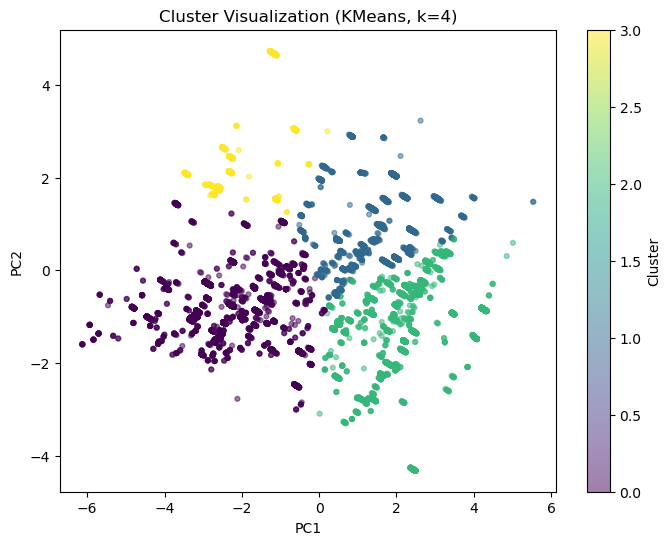

In [42]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=kmeans_labels, cmap="viridis", alpha=0.5, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Cluster Visualization (KMeans, k={best_k})")
plt.colorbar(scatter, label="Cluster")
plt.show()


## 9. Save the Clustering Results

In [43]:
results = df.copy()
results["kmeans_cluster"] = kmeans_labels
results["agglomerative_cluster"] = agg_labels

results.to_csv(CLUSTERING_RESULTS_CSV, index=False)
print(f"Saved {CLUSTERING_RESULTS_CSV}")


Saved clustering_results.csv
